In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
data_dir = '/kaggle/input/datasets/vilquer/wikitext-2'
train_path = os.path.join(data_dir, 'wiki.train.tokens')
valid_path = os.path.join(data_dir, 'wiki.valid.tokens')
test_path = os.path.join(data_dir, 'wiki.test.tokens')

def load_tokens(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read().split()

print("Loading raw text...")
train_tokens = load_tokens(train_path)
valid_tokens = load_tokens(valid_path)
test_tokens = load_tokens(test_path)

# ---------------------------------------------------------
# BULLETPROOF VOCABULARY BUILDER
# ---------------------------------------------------------
max_vocab_size = 30000 
counter = Counter(train_tokens)

# 1. Get the most common words
most_common_words = [word for word, count in counter.most_common(max_vocab_size)]

# 2. Build dictionary safely: Force <unk> to 0, and add the rest sequentially
vocab = {'<unk>': 0}
for word in most_common_words:
    if word not in vocab: # Prevents adding <unk> twice if it was in the text
        vocab[word] = len(vocab)

# 3. Set global vocab size
vocab_size = len(vocab) 
print(f"Final Vocabulary Size: {vocab_size} tokens")
print(f"Highest Token ID: {max(vocab.values())}") # This will safely be vocab_size - 1

Loading raw text...
Final Vocabulary Size: 30000 tokens
Highest Token ID: 29999


In [3]:
def encode(tokens):
    return [vocab.get(w, 0) for w in tokens]

class LMDataset(Dataset):
    def __init__(self, data_ids, seq_len):
        self.seq_len = seq_len
        num_samples = (len(data_ids) - 1) // seq_len
        self.data = data_ids[:num_samples * seq_len + 1]

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        i = idx * self.seq_len
        x = self.data[i : i + self.seq_len]
        y = self.data[i + 1 : i + self.seq_len + 1]
        return x, y

batch_size = 32
train_seq_len = 128
extrapolate_seq_len = 256

print("Encoding tokens to tensors...")
train_ids = torch.tensor(encode(train_tokens), dtype=torch.long)
valid_ids = torch.tensor(encode(valid_tokens), dtype=torch.long)
test_ids = torch.tensor(encode(test_tokens), dtype=torch.long)

# Initialize DataLoaders
train_loader = DataLoader(LMDataset(train_ids, train_seq_len), batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(LMDataset(valid_ids, train_seq_len), batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(LMDataset(test_ids, train_seq_len), batch_size=batch_size, shuffle=False, drop_last=True)

# DataLoader for Length Generalization Testing (Double Sequence Length)
valid_ext_loader = DataLoader(LMDataset(valid_ids, extrapolate_seq_len), batch_size=batch_size, shuffle=False, drop_last=True)

print(f"DataLoaders ready. Train batches: {len(train_loader)}")

Encoding tokens to tensors...
DataLoaders ready. Train batches: 500


In [4]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) 

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :], None 

class LearnedPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)

    def forward(self, x):
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0).expand(x.size(0), -1)
        return x + self.pe(positions), None

class RotaryPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model
        inv_freq = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, x):
        t = torch.arange(x.size(1), device=x.device).type_as(self.inv_freq)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        return x, torch.cat((freqs, freqs), dim=-1)

def apply_rotary_pos_emb(q, k, freqs):
    cos = freqs.cos().unsqueeze(0).unsqueeze(0)
    sin = freqs.sin().unsqueeze(0).unsqueeze(0)
    def rotate_half(x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat((-x2, x1), dim=-1)
    return (q * cos) + (rotate_half(q) * sin), (k * cos) + (rotate_half(k) * sin)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None, rotary_freqs=None):
        batch_size = q.size(0)
        
        # Memory contiguity fixes are applied here
        q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2).contiguous()
        k = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2).contiguous()
        v = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2).contiguous()

        if rotary_freqs is not None:
            q, k = apply_rotary_pos_emb(q, k, rotary_freqs[..., :self.d_k])
            q, k = q.contiguous(), k.contiguous()

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.w_o(out), attn

In [5]:
class SwappablePETransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, pe_module):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe_module = pe_module
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'mha': MultiHeadAttention(d_model, num_heads),
                'norm1': nn.LayerNorm(d_model),
                'ffn': nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)),
                'norm2': nn.LayerNorm(d_model),
                'dropout': nn.Dropout(0.3)
            }) for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        # Causal mask for language modeling
        mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0).to(x.device)
        
        x = self.embedding(x)
        x, rotary_freqs = self.pe_module(x)
        
        for layer in self.layers:
            attn_out, _ = layer['mha'](x, x, x, mask, rotary_freqs)
            x = layer['norm1'](x + layer['dropout'](attn_out))
            ffn_out = layer['ffn'](x)
            x = layer['norm2'](x + layer['dropout'](ffn_out))
            
        return self.lm_head(x)

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x).view(-1, vocab_size)
        loss = criterion(outputs, y.view(-1))
        loss.backward()
        
        # Gradient clipping prevents exploding gradients in early transformer training
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x).view(-1, vocab_size)
            loss = criterion(outputs, y.view(-1))
            total_loss += loss.item()
            
    loss = total_loss / len(loader)
    ppl = math.exp(loss) if loss < 20 else float('inf')
    return loss, ppl


 TRAINING MODEL WITH: Sinusoidal PE
Epoch 01/5 | LR: 0.000500 | Train Loss: 6.0986 | Val Loss: 5.4661 | Val PPL: 236.55
Epoch 02/5 | LR: 0.000453 | Train Loss: 5.2057 | Val Loss: 5.1489 | Val PPL: 172.24
Epoch 03/5 | LR: 0.000331 | Train Loss: 4.6814 | Val Loss: 5.0132 | Val PPL: 150.38
Epoch 04/5 | LR: 0.000179 | Train Loss: 4.2634 | Val Loss: 4.9457 | Val PPL: 140.57
Epoch 05/5 | LR: 0.000057 | Train Loss: 3.9806 | Val Loss: 4.9313 | Val PPL: 138.56

--> Standard Test Set   | Loss: 4.8626 | Perplexity: 129.36
--> Extrapolation (2x)  | Loss: 5.2803 | Perplexity: 196.43

Generating performance graphs...


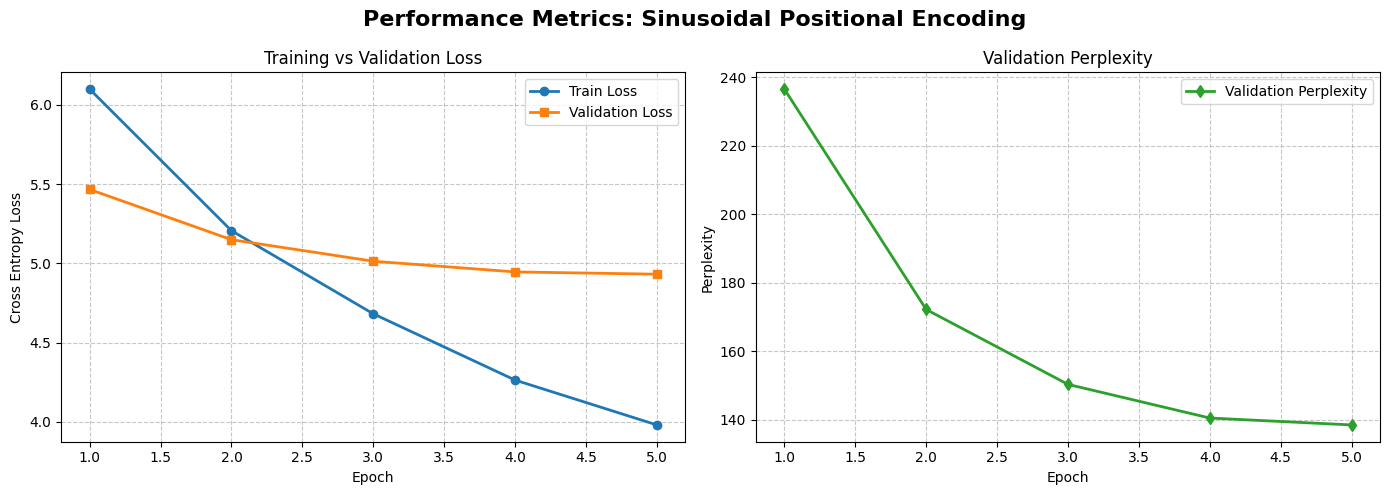

In [7]:
import math
import matplotlib.pyplot as plt
import torch.optim.lr_scheduler as lr_scheduler

# =====================================================================
# ---> THE SWAP LINE: CHANGE THIS TO "Sinusoidal", "Learned", or "RoPE"
# =====================================================================
SELECTED_PE = "Sinusoidal"  

# ==========================================
# 1. HYPERPARAMETERS & INITIALIZATION
# ==========================================
d_model = 512       
num_heads = 8       
num_layers = 6      
d_ff = 2048         
num_epochs = 5     

# Inject the selected Positional Encoding
if SELECTED_PE == "Sinusoidal":
    pe_module = SinusoidalPE(d_model)
elif SELECTED_PE == "Learned":
    pe_module = LearnedPE(d_model)
elif SELECTED_PE == "RoPE":
    pe_module = RotaryPE(d_model)
else:
    raise ValueError("Invalid PE selected! Use 'Sinusoidal', 'Learned', or 'RoPE'.")

# Build the model with the injected PE
model = SwappablePETransformer(vocab_size, d_model, num_heads, num_layers, d_ff, pe_module).to(device)
criterion = nn.CrossEntropyLoss()

# Tracking dictionaries for our graph
history = {'train_loss': [], 'val_loss': [], 'val_ppl': []}

# ==========================================
# 2. TRAINING LOOP
# ==========================================
print(f"\n======================================")
print(f" TRAINING MODEL WITH: {SELECTED_PE} PE")
print(f"======================================")

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01) 
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

for epoch in range(num_epochs): 
    # Train & Evaluate
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_ppl = evaluate(model, valid_loader, criterion)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    # Save metrics for graphing
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_ppl'].append(val_ppl)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.2f}")

# Baseline Test 
test_loss, test_ppl = evaluate(model, test_loader, criterion)
print(f"\n--> Standard Test Set   | Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f}")

# Length Generalization Test
try:
    extrap_loss, extrap_ppl = evaluate(model, valid_ext_loader, criterion)
    print(f"--> Extrapolation (2x)  | Loss: {extrap_loss:.4f} | Perplexity: {extrap_ppl:.2f}")
except Exception as e:
    print(f"--> Extrapolation (2x) FAILED: {str(e)}")

# ==========================================
# 3. GRAPH GENERATION
# ==========================================
print("\nGenerating performance graphs...")
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Performance Metrics: {SELECTED_PE} Positional Encoding", fontsize=16, fontweight='bold')

# Left Graph: Loss Curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')
axes[0].set_title("Training vs Validation Loss", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross Entropy Loss")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Right Graph: Perplexity
axes[1].plot(epochs_range, history['val_ppl'], label='Validation Perplexity', color='#2ca02c', linewidth=2, marker='d')
axes[1].set_title("Validation Perplexity", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np

# ==========================================
# AG NEWS DATA LOADING & TOKENIZATION
# ==========================================
ag_news_dir = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset'
train_csv_path = os.path.join(ag_news_dir, 'train.csv')
test_csv_path = os.path.join(ag_news_dir, 'test.csv')

print("Loading AG News CSV files...")
# Define column names since the CSV might not have a header
cols = ['class_index', 'title', 'description']
df_train = pd.read_csv(train_csv_path, names=cols, header=0)
df_test = pd.read_csv(test_csv_path, names=cols, header=0)

# The classes in AG News are 1: World, 2: Sports, 3: Business, 4: Sci/Tech
# We must shift them to 0-3 for PyTorch CrossEntropyLoss
df_train['class_index'] = df_train['class_index'] - 1
df_test['class_index'] = df_test['class_index'] - 1

ag_news_classes = ["World", "Sports", "Business", "Sci/Tech"]
num_classes = len(ag_news_classes)
cls_seq_len = 128
cls_batch_size = 32

def process_dataframe(df):
    """Combines text, tokenizes, encodes with existing vocab, and pads/truncates."""
    print(f"Processing {len(df)} articles...")
    encoded_docs = []
    labels = []
    
    for _, row in df.iterrows():
        # Combine title and description
        text = str(row['title']) + " " + str(row['description'])
        
        # Tokenize (simple split to match our WikiText pretraining)
        tokens = text.split()
        
        # Encode using the existing 'vocab' from Cell 2
        # If an AG News word wasn't in WikiText, it safely becomes 0 (<unk>)
        token_ids = [vocab.get(w, 0) for w in tokens]
        
        # Truncate if too long
        if len(token_ids) > cls_seq_len:
            token_ids = token_ids[:cls_seq_len]
        # Pad with 0s if too short
        else:
            token_ids = token_ids + [0] * (cls_seq_len - len(token_ids))
            
        encoded_docs.append(token_ids)
        labels.append(row['class_index'])
        
    return torch.tensor(encoded_docs, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

train_x, train_y = process_dataframe(df_train)
test_x, test_y = process_dataframe(df_test)

class ClassificationDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

cls_train_loader = DataLoader(ClassificationDataset(train_x, train_y), batch_size=cls_batch_size, shuffle=True)
cls_test_loader = DataLoader(ClassificationDataset(test_x, test_y), batch_size=cls_batch_size, shuffle=False)

print("Classification DataLoaders Ready!")

Loading AG News CSV files...
Processing 120000 articles...
Processing 7600 articles...
Classification DataLoaders Ready!


In [9]:
# ==========================================
# PRETRAINED MODEL WRAPPER
# ==========================================
class TransformerClassifier(nn.Module):
    def __init__(self, pretrained_lm, num_classes):
        super().__init__()
        # Steal the trained layers from the LM
        self.embedding = pretrained_lm.embedding
        self.pe_module = pretrained_lm.pe_module
        self.layers = pretrained_lm.layers
        
        # Determine the embedding dimension 
        self.d_model = pretrained_lm.lm_head.in_features
        
        # Create a brand new classification head
        self.classifier = nn.Linear(self.d_model, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.embedding(x)
        x, rotary_freqs = self.pe_module(x)
        
        # Pass through attention blocks (Bidirectional, no causal mask needed)
        for layer in self.layers:
            attn_out, _ = layer['mha'](x, x, x, mask=None, rotary_freqs=rotary_freqs)
            x = layer['norm1'](x + layer['dropout'](attn_out))
            ffn_out = layer['ffn'](x)
            x = layer['norm2'](x + layer['dropout'](ffn_out))
            
        # Mean Pooling: Average the sequence dimension to get 1 vector per article
        sentence_embedding = x.mean(dim=1) 
        
        # Classify
        sentence_embedding = self.dropout(sentence_embedding)
        return self.classifier(sentence_embedding)

# Initialize using the model we trained in the previous cells
pretrained_lm = model 
cls_model = TransformerClassifier(pretrained_lm, num_classes).to(device)
print(f"Classification model initialized using pretrained weights.")

Classification model initialized using pretrained weights.


In [10]:
# ==========================================
# FINE-TUNING EXECUTION
# ==========================================
def train_classifier_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x) 
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        
    return total_loss / len(loader), 100. * correct / total

def eval_classifier(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
    return total_loss / len(loader), 100. * correct / total

cls_criterion = nn.CrossEntropyLoss()

# VERY IMPORTANT: Use a tiny learning rate (2e-5) so we don't destroy 
# the grammar rules the model just spent 15 epochs learning!
cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=2e-5, weight_decay=0.01)

fine_tune_epochs = 3

print("\n--- Starting Fine-Tuning on AG News ---")
for epoch in range(fine_tune_epochs):
    t_loss, t_acc = train_classifier_epoch(cls_model, cls_train_loader, cls_optimizer, cls_criterion)
    v_loss, v_acc = eval_classifier(cls_model, cls_test_loader, cls_criterion)
    
    print(f"Epoch {epoch+1}/{fine_tune_epochs}")
    print(f"Train | Loss: {t_loss:.4f} | Accuracy: {t_acc:.2f}%")
    print(f"Test  | Loss: {v_loss:.4f} | Accuracy: {v_acc:.2f}%\n")


--- Starting Fine-Tuning on AG News ---
Epoch 1/3
Train | Loss: 0.4726 | Accuracy: 82.42%
Test  | Loss: 0.3704 | Accuracy: 87.72%

Epoch 2/3
Train | Loss: 0.3045 | Accuracy: 89.25%
Test  | Loss: 0.3369 | Accuracy: 89.26%

Epoch 3/3
Train | Loss: 0.2413 | Accuracy: 91.57%
Test  | Loss: 0.3547 | Accuracy: 89.13%



In [11]:
# ==========================================
# PREDICTED VS ACTUAL VISUALIZER
# ==========================================
idx_to_word = {v: k for k, v in vocab.items()}

def decode_sequence(tensor):
    """Converts a tensor of token IDs back into readable words, ignoring padding."""
    words = [idx_to_word.get(idx.item(), '<unk>') for idx in tensor if idx.item() != 0]
    return " ".join(words)

def view_predictions(model, loader, class_names, num_samples=5):
    model.eval()
    samples_shown = 0
    
    print("======================================")
    print(" PREDICTED VS ACTUAL AG NEWS SAMPLES")
    print("======================================")
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            
            for i in range(x.size(0)):
                # Decode the text
                text = decode_sequence(x[i])
                
                true_label = class_names[y[i].item()]
                pred_label = class_names[predicted[i].item()]
                
                print(f"\n📝 Text: {text[:250]}...")
                print(f"🎯 Actual:    {true_label}")
                
                if true_label == pred_label:
                    print(f"✅ Predicted: {pred_label}")
                else:
                    print(f"❌ Predicted: {pred_label}")
                
                samples_shown += 1
                if samples_shown >= num_samples:
                    return

# Run the visualizer on a batch from the test set
view_predictions(cls_model, cls_test_loader, ag_news_classes, num_samples=8)

 PREDICTED VS ACTUAL AG NEWS SAMPLES

📝 Text: for T N after talks representing workers at Turner say they are after talks with stricken parent firm Federal...
🎯 Actual:    Business
✅ Predicted: Business

📝 Text: The Race is Second Private Team Date for Human - Canada -- A of competing for the million Ansari X a contest funded space has officially announced the date for its manned...
🎯 Actual:    Sci/Tech
✅ Predicted: Sci/Tech

📝 Text: Company Wins Grant to Study AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better which are short chains of amino the building blocks of...
🎯 Actual:    Sci/Tech
✅ Predicted: Sci/Tech

📝 Text: Unit AP - barely dawn when Mike Fitzpatrick starts his shift with a of colorful figures and endless but already he knows what the day will Lightning will strike in places he Winds will pick moist places will dry and flames will...
🎯 Actual:    Sci/Tech
❌ Predicted: Sports

📝 Text: to AP -